# Causal Inference with Neural Networks: TARNet, CFR, and Dragonnet

Estimating the Individual Treatment Effect (ITE) from observational data is a fundamental challenge in causal inference. Because we never observe the counterfactual outcome (e.g., what would have happened to a treated patient if they had *not* received treatment), we must rely on models to estimate it. 

In recent years, neural network architectures have been adapted to tackle this problem. Three of the most prominent architectures are **TARNet**, **CFR** (Counterfactual Regression), and **Dragonnet**.

## 1. What are these models and how do they differ?

### TARNet (Treatment-Agnostic Representation Network)
TARNet bridges the gap between simple S-learners (which concatenate the treatment variable with covariates) and T-learners (which train completely separate models for treated and control groups). 

```mermaid
graph TD
    X[Covariates X] --> Phi[Shared Representation Φ]
    Phi --> H0[Hypothesis Head h0]
    Phi --> H1[Hypothesis Head h1]
    H0 -.-> Y0[Predict Y0]
    H1 -.-> Y1[Predict Y1]
    
    classDef rep fill:#e1f5fe,stroke:#01579b,stroke-width:2px;
    classDef head fill:#fff3e0,stroke:#e65100,stroke-width:2px;
    classDef out fill:#f1f8e9,stroke:#33691e,stroke-width:2px;
    
    class X,Phi rep;
    class H0,H1 head;
    class Y0,Y1 out;
```

TARNet learns a shared representation of the input covariates, $\Phi(X)$. This shared representation then branches into two separate "hypothesis heads":
* $h_0(\Phi(X))$ to predict the control outcome $\hat{Y}(0)$
* $h_1(\Phi(X))$ to predict the treated outcome $\hat{Y}(1)$

The loss function minimizes the factual Mean Squared Error (MSE):
$$\mathcal{L}_{TARNet} = \frac{1}{N} \sum_{i=1}^N \left( Y_i - h_{T_i}(\Phi(X_i)) \right)^2$$

### CFR (Counterfactual Regression)
CFR is a direct extension of TARNet that introduces **balance regularization**. In observational data, the distribution of covariates often differs significantly between treated and control groups (selection bias). 

```mermaid
graph TD
    X[Covariates X] --> Phi[Shared Representation Φ]
    Phi --> H0[Hypothesis Head h0]
    Phi --> H1[Hypothesis Head h1]
    Phi -.-> IPM[IPM Balance Penalty]
    H0 -.-> Y0[Predict Y0]
    H1 -.-> Y1[Predict Y1]
    
    classDef rep fill:#e1f5fe,stroke:#01579b,stroke-width:2px;
    classDef head fill:#fff3e0,stroke:#e65100,stroke-width:2px;
    classDef out fill:#f1f8e9,stroke:#33691e,stroke-width:2px;
    classDef penalty fill:#ffebee,stroke:#b71c1c,stroke-width:2px;
    
    class X,Phi rep;
    class H0,H1 head;
    class Y0,Y1 out;
    class IPM penalty;
```

CFR forces the shared representation $\Phi(X)$ to map treated and control samples into a similar distribution space. It achieves this by adding an Integral Probability Metric (IPM) penalty, such as Maximum Mean Discrepancy (MMD) or the Wasserstein distance, to the TARNet loss:
$$\mathcal{L}_{CFR} = \mathcal{L}_{TARNet} + \alpha \cdot \text{IPM}(\{\Phi(X_i)\}_{T_i=0}, \{\Phi(X_i)\}_{T_i=1})$$
By balancing the representations, CFR ensures that the model is comparing "apples to apples" when it predicts counterfactuals.

### Dragonnet
Dragonnet builds upon TARNet by explicitly incorporating the **propensity score** (the probability of receiving treatment given the covariates, $P(T=1|X)$). 

```mermaid
graph TD
    X[Covariates X] --> Phi[Shared Representation Φ]
    Phi --> H0[Hypothesis Head h0]
    Phi --> H1[Hypothesis Head h1]
    Phi --> Prop[Propensity Head]
    H0 -.-> Y0[Predict Y0]
    H1 -.-> Y1[Predict Y1]
    Prop -.-> T[Predict T]
    
    classDef rep fill:#e1f5fe,stroke:#01579b,stroke-width:2px;
    classDef head fill:#fff3e0,stroke:#e65100,stroke-width:2px;
    classDef out fill:#f1f8e9,stroke:#33691e,stroke-width:2px;
    classDef prop fill:#f3e5f5,stroke:#4a148c,stroke-width:2px;
    
    class X,Phi rep;
    class H0,H1 head;
    class Y0,Y1,T out;
    class Prop prop;
```


Instead of regularizing the distribution via an IPM, Dragonnet adds a *third head* to the shared representation $\Phi(X)$ specifically to predict the propensity score.
$$\mathcal{L}_{Dragonnet} = \mathcal{L}_{TARNet} + \beta \cdot \text{CrossEntropy}(T_i, p(\Phi(X_i)))$$
By forcing the shared representation to predict treatment assignment, Dragonnet ensures that all features that confound the treatment decision are preserved in $\Phi(X)$. This is known as "sufficiency" and leads to statistically efficient estimates of the Average Treatment Effect (ATE).

---

## 2. Evaluating TARNet on the IHDP Dataset

To see these concepts in action, we will evaluate TARNet on the **IHDP (Infant Health and Development Program)** dataset. IHDP is a gold standard benchmark because it is *semi-simulated*: covariates and treatment assignments are from a real experiment, but outcomes are simulated. This gives us access to ground truth counterfactuals to compute the PEHE (Precision in Estimation of Heterogeneous Effects).

Here is how to map IHDP to the TARNet architecture using PyTorch.

### Step 1: The Shared Representation

The core of TARNet relies on learning a **shared latent representation** of the covariates. Instead of estimating $Y$ directly from $X$, the network first passes the covariates through a series of shared layers to extract a dense feature embedding:

$$ \Phi(X) = \text{SharedLayers}(X) $$

This ensures that the model learns features that are generally useful for predicting the outcome, regardless of the treatment assignment. In causal inference, this embedding function $\Phi(X)$ is crucial because it creates a common basis for estimating both the treated and control potential outcomes.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SharedRepresentation(nn.Module):
    def __init__(self, input_dim=25, hidden_dim=200):
        super().__init__()
        # 3 dense layers learning a shared representation
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ELU()
        )
        
    def forward(self, x):
        h = self.network(x)
        # CFRNet applies L2 normalization to the shared representation
        return F.normalize(h, p=2, dim=1)

### Step 2: The Treatment Split

After extracting the shared representation $\Phi(X)$, the architecture bifurcates into two distinct **Hypothesis Heads** (also called outcome branches). 

One head is dedicated to estimating the control outcome, and the other is dedicated to estimating the treated outcome:

$$ \hat{Y}(0) = h_0(\Phi(X)) $$
$$ \hat{Y}(1) = h_1(\Phi(X)) $$

During the forward pass, data is routed dynamically to the appropriate head based on the actual observed treatment assignment $T$. The unobserved counterfactual is simply ignored during training. By decoupling the hypothesis heads, TARNet mitigates the risk of the model simply "ignoring" the treatment variable $T$, which is a common failure mode when $T$ is just concatenated as an additional input feature.

In [2]:
class HypothesisHead(nn.Module):
    def __init__(self, input_dim=200, hidden_dim=100):
        super().__init__()
        # 3 dense layers predicting the counterfactual, followed by linear prediction
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, 1) # Predicts the outcome Y
        )
        
    def forward(self, phi):
        return self.network(phi)

class TARNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.phi = SharedRepresentation(input_dim=25, hidden_dim=200)
        self.h0 = HypothesisHead(input_dim=200, hidden_dim=100)
        self.h1 = HypothesisHead(input_dim=200, hidden_dim=100)
        
    def forward(self, x, t):
        # 1. Get shared representation
        phi = self.phi(x)
        
        # 2. Predict both counterfactuals
        y0_hat = self.h0(phi)
        y1_hat = self.h1(phi)
        
        # 3. Select the factual prediction based on treatment assignment t
        y_hat = (1 - t) * y0_hat + t * y1_hat
        
        return y_hat, y0_hat, y1_hat

### Step 3: The Objective Function

We train TARNet by minimizing the **Factual Mean Squared Error (MSE)**. Because we only ever observe the factual outcome $Y_i$ associated with the given treatment $T_i$, we calculate the loss strictly on the observed pairs. 

The empirical loss function is defined as:

$$ \mathcal{L}_{\text{TARNet}} = \frac{1}{N} \sum_{i=1}^N \left( y_i - \hat{Y}(T_i) \right)^2 $$

Where $\hat{Y}(T_i) = h_{T_i}(\Phi(x_i))$. Unlike more complex models like CFR (Counterfactual Regression) or Dragonnet, TARNet relies solely on the architectural split to learn treatment effects; it does not apply representation balance penalties (like MMD or Wasserstein distances) or propensity score regularization.

In [3]:
def tarnet_loss(y_true, y_hat):
    """
    Computes the Mean Squared Error on the observed (factual) outcomes.
    """
    criterion = nn.MSELoss()
    return criterion(y_hat, y_true)

### Step 4: Data Fetching and Preprocessing

To truly evaluate our model, we use the full 1000-realization **Infant Health and Development Program (IHDP)** dataset exactly as used in the CFRNet paper. 

This dataset provides 1000 distinct, simulated outcome surfaces over the same real-world covariates, allowing us to robustly estimate expected performance. The data is provided in `.npz` format, which includes pre-defined train and test splits, ensuring our in-sample and out-of-sample metrics are strictly rigorous.

In [4]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load the official full 1000-replication NPZ dataset
d_train = np.load('ihdp_full/ihdp_npci_1-1000.train.npz')
d_test = np.load('ihdp_full/ihdp_npci_1-1000.test.npz')

# Extract arrays
x_train_all = torch.FloatTensor(d_train['x']).to(device)               # Shape (N, 25, 1000)
t_train_all = torch.FloatTensor(d_train['t']).unsqueeze(2).to(device)  # Shape (N, 1000, 1)
yf_train_all = torch.FloatTensor(d_train['yf']).unsqueeze(2).to(device)# Shape (N, 1000, 1)
mu0_train_all = d_train['mu0']                                         # Shape (N, 1000)
mu1_train_all = d_train['mu1']                                         # Shape (N, 1000)

x_test_all = torch.FloatTensor(d_test['x']).to(device)                 # Shape (N_test, 25, 1000)
t_test_all = torch.FloatTensor(d_test['t']).unsqueeze(2).to(device)
yf_test_all = torch.FloatTensor(d_test['yf']).unsqueeze(2).to(device)
mu0_test_all = d_test['mu0']
mu1_test_all = d_test['mu1']

num_replications = x_train_all.shape[2]
print(f"Loaded {num_replications} replications. Train shape: {x_train_all.shape}, Test shape: {x_test_all.shape}")

Using device: cuda
Loaded 1000 replications. Train shape: torch.Size([672, 25, 1000]), Test shape: torch.Size([75, 25, 1000])


### Step 5: Training Loop

For this tutorial, we will select a single realization (`rep = 0`) from the dataset to train and evaluate our TARNet model. We will implement the full 1000-replication benchmark using Python multiprocessing in a separate script later!

We initialize the model, set up the PyTorch `DataLoader`, and train for exactly 3000 mini-batch iterations (as configured in the original CFRNet codebase).

In [5]:
iterations = 3000
batch_size = 100
rep = 0 # Choose the first realization

print(f"Training on Realization {rep}...")

# Slice the data for this replication
x_tr, t_tr, y_tr = x_train_all[:, :, rep], t_train_all[:, rep, :], yf_train_all[:, rep, :]
x_te, t_te = x_test_all[:, :, rep], t_test_all[:, rep, :]

# Create DataLoader
dataset_train = TensorDataset(x_tr, t_tr, y_tr)
dataloader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)

# Initialize fresh model on GPU
tarnet = TARNet().to(device)
optimizer = torch.optim.Adam(tarnet.parameters(), lr=1e-3, weight_decay=1e-4)
tarnet.train()

# Train for exactly 3000 iterations
current_iter = 0
while current_iter < iterations:
    for batch_x, batch_t, batch_y in dataloader_train:
        if current_iter >= iterations:
            break
            
        optimizer.zero_grad()
        y_hat, _, _ = tarnet(batch_x, batch_t)
        loss = tarnet_loss(batch_y, y_hat)
        loss.backward()
        optimizer.step()
        
        current_iter += 1

print("Training complete!")

Training on Realization 0...
Training complete!


### Step 6: Evaluation and Visualization

Now that the model is trained, we evaluate its counterfactual estimation power using **PEHE** (Mean Squared Error of the ITE).

We visualize the Estimated ITE vs the True ITE for this specific realization on a scatter plot. A perfectly performing model would place all points directly on the $y=x$ ideal line.

In-Sample PEHE (MSE):     2.9084
Out-of-Sample PEHE (MSE): 3.7865
Out-of-Sample RMSE:       1.9459


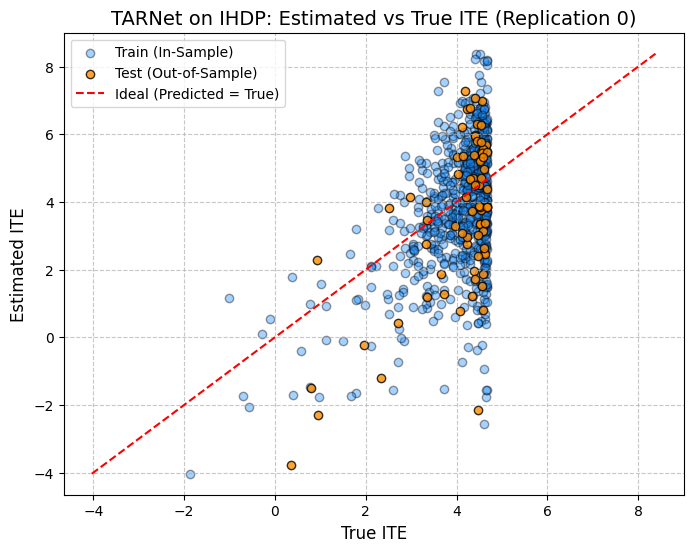

In [6]:
import matplotlib.pyplot as plt
import numpy as np

tarnet.eval()
with torch.no_grad():
    # In-Sample PEHE
    _, y0_hat_in, y1_hat_in = tarnet(x_tr, t_tr)
    ite_hat_in = (y1_hat_in - y0_hat_in).cpu().numpy()
    ite_true_in = mu1_train_all[:, rep:rep+1] - mu0_train_all[:, rep:rep+1]
    pehe_in = np.mean((ite_true_in - ite_hat_in)**2)
    
    # Out-of-Sample PEHE
    _, y0_hat_out, y1_hat_out = tarnet(x_te, t_te)
    ite_hat_out = (y1_hat_out - y0_hat_out).cpu().numpy()
    ite_true_out = mu1_test_all[:, rep:rep+1] - mu0_test_all[:, rep:rep+1]
    pehe_out = np.mean((ite_true_out - ite_hat_out)**2)

print(f"In-Sample PEHE (MSE):     {pehe_in:.4f}")
print(f"Out-of-Sample PEHE (MSE): {pehe_out:.4f}")
print(f"Out-of-Sample RMSE:       {np.sqrt(pehe_out):.4f}")

plt.figure(figsize=(8, 6))

# Plot train set
plt.scatter(ite_true_in, ite_hat_in, alpha=0.4, color='dodgerblue', edgecolor='k', label='Train (In-Sample)')

# Plot test set
plt.scatter(ite_true_out, ite_hat_out, alpha=0.8, color='darkorange', edgecolor='k', label='Test (Out-of-Sample)')

# Add y=x ideal line
min_val = min(np.min(ite_true_in), np.min(ite_hat_in), np.min(ite_true_out), np.min(ite_hat_out))
max_val = max(np.max(ite_true_in), np.max(ite_hat_in), np.max(ite_true_out), np.max(ite_hat_out))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal (Predicted = True)')

plt.title(f'TARNet on IHDP: Estimated vs True ITE (Replication {rep})', fontsize=14)
plt.xlabel('True ITE', fontsize=12)
plt.ylabel('Estimated ITE', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

---
## 3. Counterfactual Regression (CFR)

TARNet solves the problem of treatment ignorance by structurally decoupling the hypothesis heads. However, TARNet has no mechanism to ensure that the shared representation $\Phi(X)$ is balanced across the treated and control groups.

**CFR (Counterfactual Regression)** solves this. It uses the exact same neural architecture as TARNet, but it introduces an **Integral Probability Metric (IPM)** regularization penalty to the loss function. This penalty forces the distributions of the treated and control representations to be as close as possible:

$$ \mathcal{L}_{CFR} = \mathcal{L}_{Factual} + \alpha \cdot \text{IPM}(\Phi(X_{t=0}), \Phi(X_{t=1})) $$

The original CFRNet paper introduced two specific IPMs: **Maximum Mean Discrepancy (MMD)** and the **Wasserstein Distance**. Let's implement both!

In [7]:
# PyTorch implementations of MMD and Sinkhorn-Wasserstein
# Adapted directly from the original CFRNet TensorFlow codebase.

def mmd2_lin(X, t, p):
    ''' Linear MMD (Maximum Mean Discrepancy) '''
    it = (t > 0).nonzero(as_tuple=True)[0]
    ic = (t < 1).nonzero(as_tuple=True)[0]

    Xc = X[ic]
    Xt = X[it]

    # Handle edge case if a batch has no treated or no control samples
    if Xc.shape[0] == 0 or Xt.shape[0] == 0:
        return torch.tensor(0.0, device=X.device, requires_grad=True)

    mean_control = torch.mean(Xc, dim=0)
    mean_treated = torch.mean(Xt, dim=0)

    mmd = torch.sum(torch.square(2.0 * p * mean_treated - 2.0 * (1.0 - p) * mean_control))
    return mmd

def pdist2sq(X, Y):
    ''' Squared euclidean distance matrix '''
    nx = torch.sum(torch.square(X), dim=1, keepdim=True)
    ny = torch.sum(torch.square(Y), dim=1, keepdim=True)
    D = -2 * torch.matmul(X, Y.t()) + ny.t() + nx
    return D

def wasserstein(X, t, p, lam=10.0, its=10, sq=False, backpropT=False):
    ''' Sinkhorn-Knopp approximation of Wasserstein distance '''
    it = (t > 0).nonzero(as_tuple=True)[0]
    ic = (t < 1).nonzero(as_tuple=True)[0]
    Xc = X[ic]
    Xt = X[it]
    nc = float(Xc.shape[0])
    nt = float(Xt.shape[0])
    
    if nc == 0 or nt == 0:
        return torch.tensor(0.0, device=X.device, requires_grad=True)

    if sq:
        M = pdist2sq(Xt, Xc)
    else:
        M = torch.sqrt(torch.clamp(pdist2sq(Xt, Xc), min=1e-10))

    M_mean = torch.mean(M)
    delta = torch.max(M).detach()
    eff_lam = (lam / M_mean).detach()

    # Pad M
    row = delta * torch.ones(1, M.shape[1], device=X.device)
    Mt = torch.cat((M, row), dim=0)
    col = torch.cat((delta * torch.ones(M.shape[0], 1, device=X.device), torch.zeros(1, 1, device=X.device)), dim=0)
    Mt = torch.cat((Mt, col), dim=1)

    a = torch.cat((p * torch.ones(Xt.shape[0], 1, device=X.device) / nt, (1 - p) * torch.ones(1, 1, device=X.device)), dim=0)
    b = torch.cat(((1 - p) * torch.ones(Xc.shape[0], 1, device=X.device) / nc, p * torch.ones(1, 1, device=X.device)), dim=0)

    Mlam = eff_lam * Mt
    K = torch.exp(-Mlam) + 1e-6
    ainvK = K / a

    u = a
    for _ in range(its):
        u = 1.0 / torch.matmul(ainvK, (b / torch.matmul(K.t(), u)))
    v = b / torch.matmul(K.t(), u)

    T = u * (v.t() * K)

    if not backpropT:
        T = T.detach()

    E = T * Mt
    D = 2 * torch.sum(E)
    return D

### Step 1: CFRNet Architecture

Since CFR uses the identical layers as TARNet, we can just inherit from our `TARNet` class! 
The only structural change is that our `forward` function must also return the shared representation $\Phi(X)$ so we can calculate the IPM penalty on it during the training loop.

In [8]:
class CFRNet(TARNet):
    def forward(self, x, t):
        # 1. Get shared representation
        phi = self.phi(x)
        
        # 2. Predict counterfactuals
        y0_hat = self.h0(phi)
        y1_hat = self.h1(phi)
        
        # 3. Select factual prediction
        y_hat = (1 - t) * y0_hat + t * y1_hat
        
        # Return `phi` alongside predictions!
        return y_hat, y0_hat, y1_hat, phi

### Step 2: Training CFR-MMD

We will first train **CFR-MMD**. We'll use the exact same realization (`rep=0`) as before. The objective function is modified to add `alpha * mmd2_lin`.

In [20]:
print(f"Training CFR-MMD on Realization {rep}...")

cfr_mmd = CFRNet().to(device)
optimizer_mmd = torch.optim.Adam(cfr_mmd.parameters(), lr=1e-3, weight_decay=1e-4)

# CFR hyperparameters
alpha = 1
p_treated = float(t_tr.mean())

cfr_mmd.train()
current_iter = 0
while current_iter < iterations:
    for batch_x, batch_t, batch_y in dataloader_train:
        if current_iter >= iterations:
            break
            
        optimizer_mmd.zero_grad()
        y_hat, _, _, phi = cfr_mmd(batch_x, batch_t)
        
        # Factual MSE Loss
        loss_factual = tarnet_loss(batch_y, y_hat)
        
        # MMD Penalty
        loss_ipm = mmd2_lin(phi, batch_t, p_treated)
        
        # Total Objective
        loss = loss_factual + alpha * loss_ipm
        
        loss.backward()
        optimizer_mmd.step()
        current_iter += 1

print("CFR-MMD Training complete!")

Training CFR-MMD on Realization 0...
CFR-MMD Training complete!


### Step 3: Evaluating CFR-MMD

CFR-MMD In-Sample PEHE (MSE):     3.4073
CFR-MMD Out-of-Sample PEHE (MSE): 4.1770


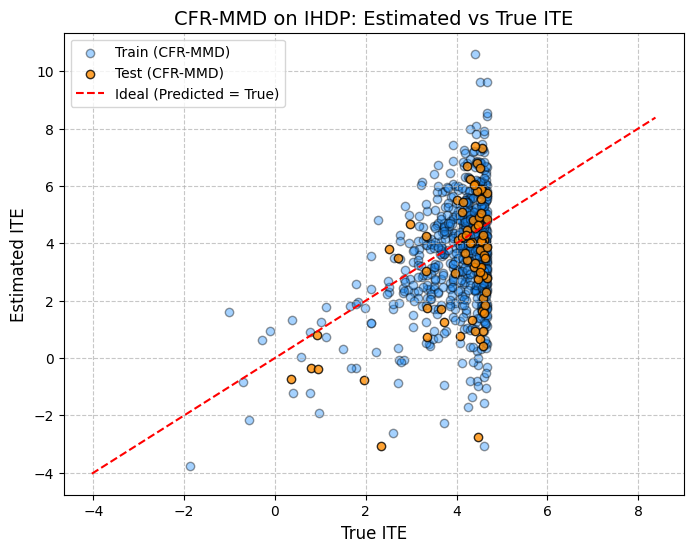

In [21]:
cfr_mmd.eval()
with torch.no_grad():
    _, y0_hat_in, y1_hat_in, _ = cfr_mmd(x_tr, t_tr)
    ite_hat_in = (y1_hat_in - y0_hat_in).cpu().numpy()
    
    _, y0_hat_out, y1_hat_out, _ = cfr_mmd(x_te, t_te)
    ite_hat_out = (y1_hat_out - y0_hat_out).cpu().numpy()

pehe_in_mmd = np.mean((ite_true_in - ite_hat_in)**2)
pehe_out_mmd = np.mean((ite_true_out - ite_hat_out)**2)

print(f"CFR-MMD In-Sample PEHE (MSE):     {pehe_in_mmd:.4f}")
print(f"CFR-MMD Out-of-Sample PEHE (MSE): {pehe_out_mmd:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(ite_true_in, ite_hat_in, alpha=0.4, color='dodgerblue', edgecolor='k', label='Train (CFR-MMD)')
plt.scatter(ite_true_out, ite_hat_out, alpha=0.8, color='darkorange', edgecolor='k', label=f'Test (CFR-MMD)')
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal (Predicted = True)')
plt.title(f'CFR-MMD on IHDP: Estimated vs True ITE', fontsize=14)
plt.xlabel('True ITE', fontsize=12)
plt.ylabel('Estimated ITE', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Step 4: Training CFR-WASS

Finally, we'll train **CFR-WASS** using the Wasserstein distance as the balancing penalty. This matches the exact hyperparameter setup from the original CFRNet paper for the IHDP dataset (`wass_lambda = 10.0`).

In [22]:
print(f"Training CFR-WASS on Realization {rep}...")

cfr_wass = CFRNet().to(device)
optimizer_wass = torch.optim.Adam(cfr_wass.parameters(), lr=1e-3, weight_decay=1e-4)

# CFR-WASS hyperparameters
alpha = 1
wass_lambda = 1.0

cfr_wass.train()
current_iter = 0
while current_iter < iterations:
    for batch_x, batch_t, batch_y in dataloader_train:
        if current_iter >= iterations:
            break
            
        optimizer_wass.zero_grad()
        y_hat, _, _, phi = cfr_wass(batch_x, batch_t)
        
        # Factual MSE Loss
        loss_factual = tarnet_loss(batch_y, y_hat)
        
        # Wasserstein Penalty
        loss_ipm = wasserstein(phi, batch_t, p_treated, lam=wass_lambda, its=20)
        
        # Total Objective
        loss = loss_factual + alpha * loss_ipm
        
        loss.backward()
        optimizer_wass.step()
        current_iter += 1

print("CFR-WASS Training complete!")

Training CFR-WASS on Realization 0...
CFR-WASS Training complete!


CFR-WASS In-Sample PEHE (MSE):     2.4132
CFR-WASS Out-of-Sample PEHE (MSE): 3.6785


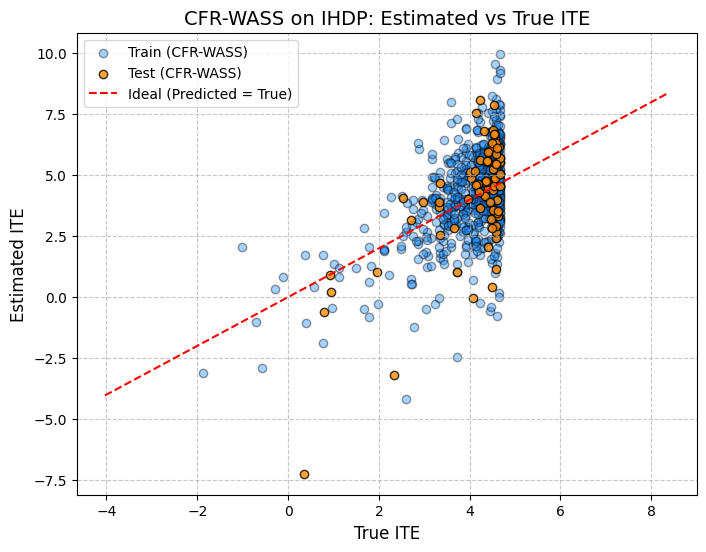

In [23]:
cfr_wass.eval()
with torch.no_grad():
    _, y0_hat_in, y1_hat_in, _ = cfr_wass(x_tr, t_tr)
    ite_hat_in = (y1_hat_in - y0_hat_in).cpu().numpy()
    
    _, y0_hat_out, y1_hat_out, _ = cfr_wass(x_te, t_te)
    ite_hat_out = (y1_hat_out - y0_hat_out).cpu().numpy()

pehe_in_wass = np.mean((ite_true_in - ite_hat_in)**2)
pehe_out_wass = np.mean((ite_true_out - ite_hat_out)**2)

print(f"CFR-WASS In-Sample PEHE (MSE):     {pehe_in_wass:.4f}")
print(f"CFR-WASS Out-of-Sample PEHE (MSE): {pehe_out_wass:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(ite_true_in, ite_hat_in, alpha=0.4, color='dodgerblue', edgecolor='k', label='Train (CFR-WASS)')
plt.scatter(ite_true_out, ite_hat_out, alpha=0.8, color='darkorange', edgecolor='k', label=f'Test (CFR-WASS)')
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal (Predicted = True)')
plt.title(f'CFR-WASS on IHDP: Estimated vs True ITE', fontsize=14)
plt.xlabel('True ITE', fontsize=12)
plt.ylabel('Estimated ITE', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Step 5: Visualizing the Learned Representations

To truly understand how Counterfactual Regression works, we can visualize the high-dimensional latent representation $\Phi(X)$ that each model learns!

We will extract the 200-dimensional representations from `TARNet`, `CFR-MMD`, and `CFR-WASS` for the training set, and use **PCA** (Principal Component Analysis) and **t-SNE** to reduce them down to 2 dimensions. 

If the IPM penalty is doing its job, the `CFR` representations should show the Treated and Control groups heavily overlapped and mixed together (discarding treatment bias), whereas `TARNet` might naturally separate them into distinct clusters!

Running PCA & t-SNE... (t-SNE takes a few seconds)


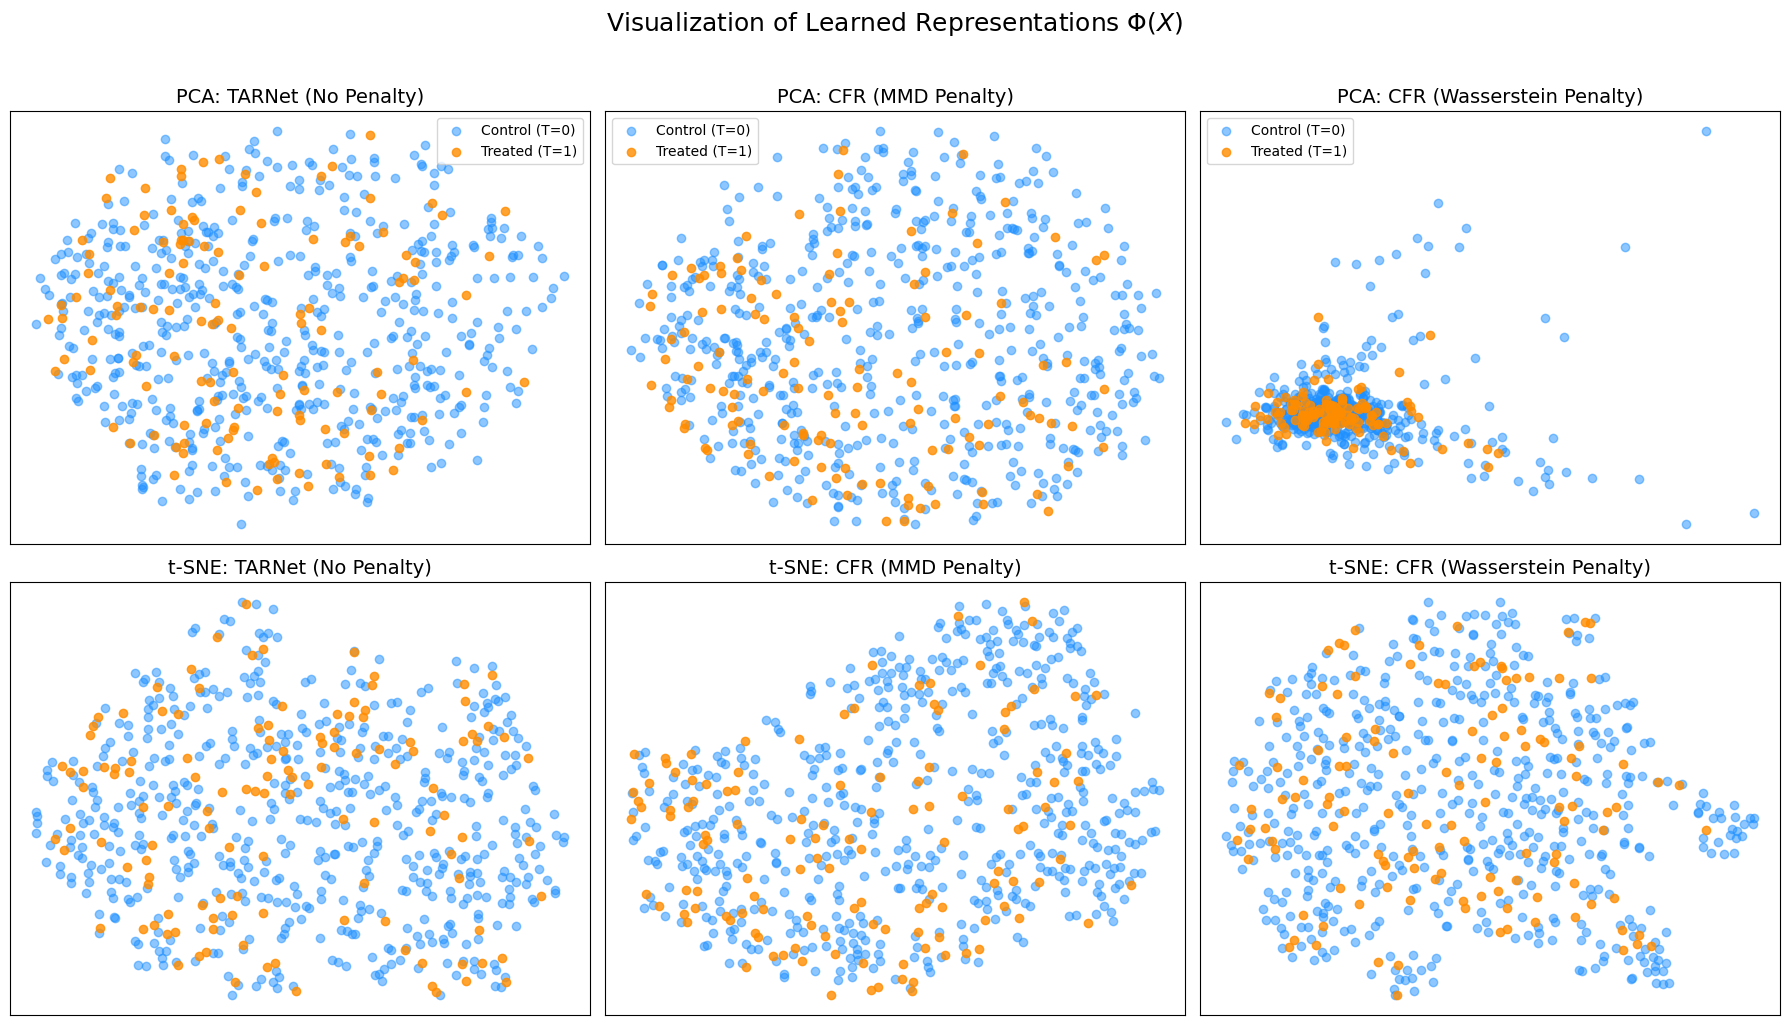

In [25]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Extract representations from the training set
tarnet.eval()
cfr_mmd.eval()
cfr_wass.eval()

with torch.no_grad():
    # TARNet's forward doesn't return phi, but we can just call its `phi` module directly
    phi_tarnet = tarnet.phi(x_tr).cpu().numpy()
    
    # CFR returns phi directly
    _, _, _, phi_mmd = cfr_mmd(x_tr, t_tr)
    phi_mmd = phi_mmd.cpu().numpy()
    
    _, _, _, phi_wass = cfr_wass(x_tr, t_tr)
    phi_wass = phi_wass.cpu().numpy()

# 2. Apply PCA and t-SNE
print("Running PCA & t-SNE... (t-SNE takes a few seconds)")
pca = PCA(n_components=2, random_state=42)
z_pca_tarnet = pca.fit_transform(phi_tarnet)
z_pca_mmd = pca.fit_transform(phi_mmd)
z_pca_wass = pca.fit_transform(phi_wass)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
z_tsne_tarnet = tsne.fit_transform(phi_tarnet)
z_tsne_mmd = tsne.fit_transform(phi_mmd)
z_tsne_wass = tsne.fit_transform(phi_wass)

# 3. Plot the distributions
t_np = t_tr.cpu().numpy().flatten()
idx_t0 = (t_np == 0)
idx_t1 = (t_np == 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
titles = ['TARNet (No Penalty)', 'CFR (MMD Penalty)', 'CFR (Wasserstein Penalty)']
pca_embeddings = [z_pca_tarnet, z_pca_mmd, z_pca_wass]
tsne_embeddings = [z_tsne_tarnet, z_tsne_mmd, z_tsne_wass]

# Plot PCA
for ax, z, title in zip(axes[0], pca_embeddings, titles):
    ax.scatter(z[idx_t0, 0], z[idx_t0, 1], alpha=0.5, label='Control (T=0)', color='dodgerblue')
    ax.scatter(z[idx_t1, 0], z[idx_t1, 1], alpha=0.8, label='Treated (T=1)', color='darkorange')
    ax.set_title(f"PCA: {title}", fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend()

# Plot t-SNE
for ax, z, title in zip(axes[1], tsne_embeddings, titles):
    ax.scatter(z[idx_t0, 0], z[idx_t0, 1], alpha=0.5, label='Control (T=0)', color='dodgerblue')
    ax.scatter(z[idx_t1, 0], z[idx_t1, 1], alpha=0.8, label='Treated (T=1)', color='darkorange')
    ax.set_title(f"t-SNE: {title}", fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('Visualization of Learned Representations $\\Phi(X)$', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()